### MSCS 634: Advanced Big Data & Data Mining

**Lab Assignment 1:** Data Preprocessing and Statistical Analysis  
**Dataset:** Sample Superstore Dataset (Kaggle)

---
### STEP 1: DATA COLLECTION

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,5)
sns.set_theme(style = 'whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


In [ ]:
# Load the Superstore dataset
# Download from: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
# Place 'Sample - Superstore.csv' in the same folder as this notebook

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()


In [11]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Quick sample
df.sample(5, random_state=42)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3125,3126,CA-2015-121720,2015-06-11,2015-06-12,First Class,JE-15610,Jim Epp,Corporate,United States,Lakeland,...,33801,South,OFF-ST-10003816,Office Supplies,Storage,Fellowes High-Stak Drawer Files,563.808,4,0.2,21.1428
1441,1442,CA-2017-128160,2017-12-19,2017-12-24,Second Class,MM-17920,Michael Moore,Consumer,United States,San Francisco,...,94110,West,OFF-BI-10001510,Office Supplies,Binders,Deluxe Heavy-Duty Vinyl Round Ring Binder,36.672,2,0.2,11.4600
4510,4511,CA-2016-119935,2016-11-10,2016-11-14,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,Springfield,...,65807,Central,FUR-FU-10001085,Furniture,Furnishings,3M Polarizing Light Filter Sleeves,37.300,2,0.0,17.1580
39,40,CA-2015-117415,2015-12-27,2015-12-31,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Houston,...,77041,Central,FUR-CH-10004218,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",212.058,3,0.3,-15.1470
4509,4510,CA-2017-167003,2017-05-23,2017-05-29,Standard Class,VS-21820,Vivek Sundaresam,Consumer,United States,Los Angeles,...,90036,West,FUR-TA-10001520,Furniture,Tables,"Lesro Sheffield Collection Coffee Table, End T...",171.288,3,0.2,-6.4233


---
### STEP 2: DATA VISUALIZATION

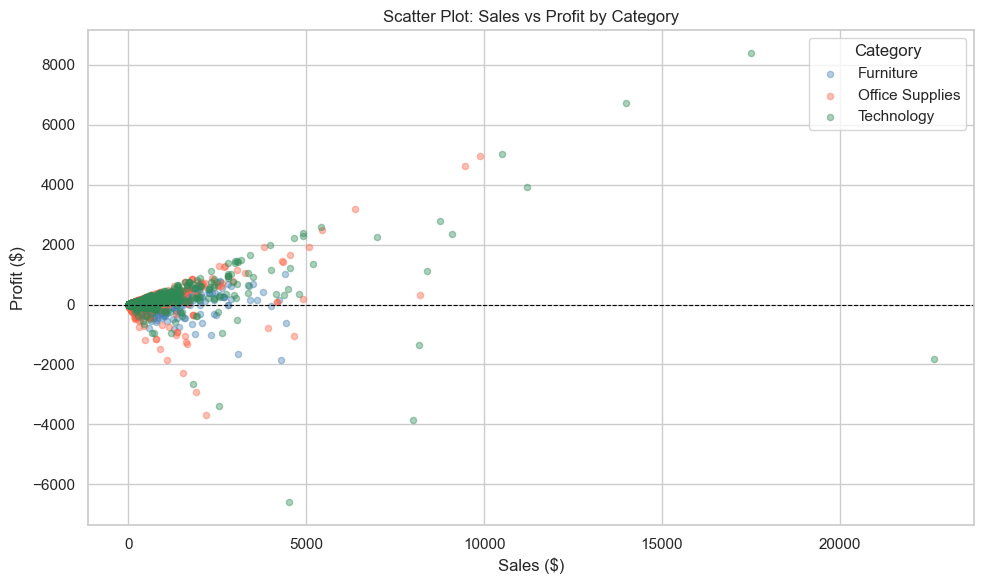

In [12]:
# ---- 2.1  Scatter Plot: Sales vs Profit colored by Category ----
fig, ax = plt.subplots(figsize=(10, 6))
categories = df['Category'].unique()
colors = ['steelblue', 'tomato', 'seagreen']
for cat, color in zip(categories, colors):
    subset = df[df['Category'] == cat]
    ax.scatter(subset['Sales'], subset['Profit'], label=cat,
               alpha=0.4, s=20, color=color)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
ax.set_title('Scatter Plot: Sales vs Profit by Category')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('viz_scatter.png', dpi=150)
plt.show()

**Insight – Scatter Plot:** There is a generally positive relationship between Sales and Profit, but many transactions fall below the zero-profit line (dashed), indicating losses likely driven by heavy discounting. Technology items (blue) tend to cluster at higher sales values with better profit margins, while Office Supplies (green) show many small-value, low-margin transactions.

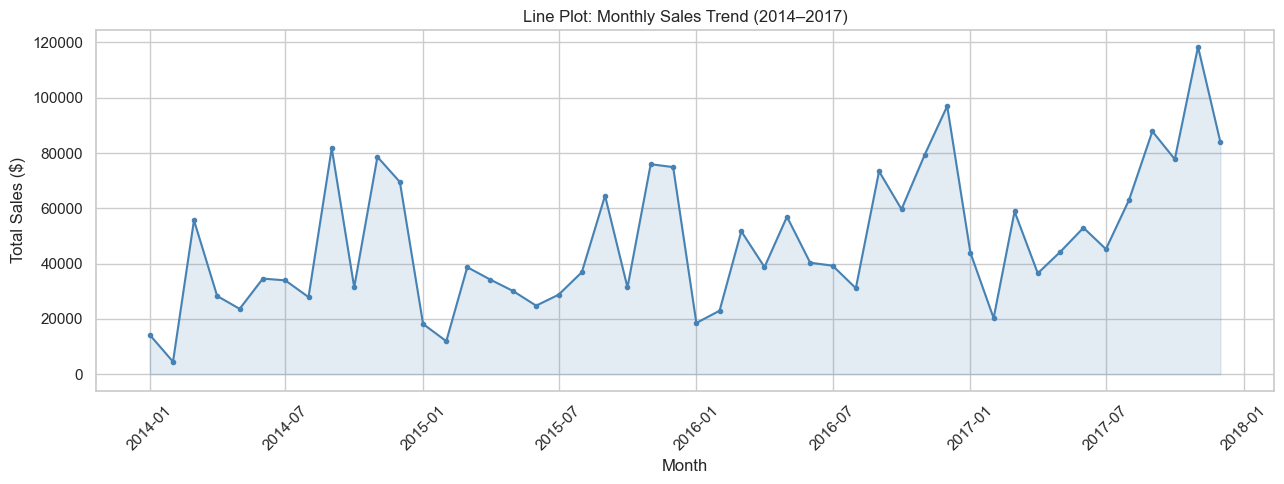

In [14]:
# ---- 2.2  Line Plot: Monthly Sales Trend ----
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_sales.index, monthly_sales.values, color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.15, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Line Plot: Monthly Sales Trend (2014–2017)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_line.png', dpi=150)
plt.show()

**Insight – Line Plot:** Sales show a clear upward trend year-over-year from 2014 to 2017. There is a consistent seasonal pattern with peaks in Q4 (October–December) each year, likely driven by holiday shopping. The lowest points typically occur in Q1 (January–February), suggesting a post-holiday slowdown.

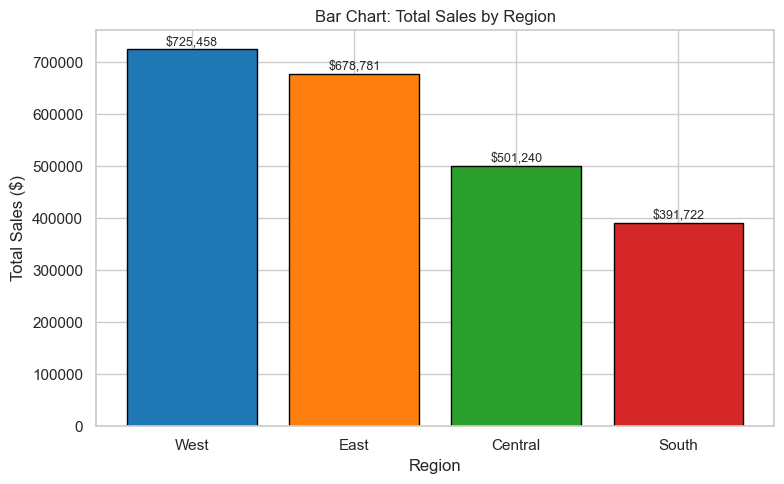

In [15]:
# ---- 2.3  Bar Chart: Total Sales by Region ----
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(region_sales.index, region_sales.values,
              color=sns.color_palette('tab10', len(region_sales)), edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Bar Chart: Total Sales by Region')
plt.tight_layout()
plt.savefig('viz_bar.png', dpi=150)
plt.show()

**Insight – Bar Chart:** The West region leads total sales, followed by East, Central, and South. The West and East together account for the majority of revenue, suggesting the business has stronger market penetration on the coasts than in the interior of the country.

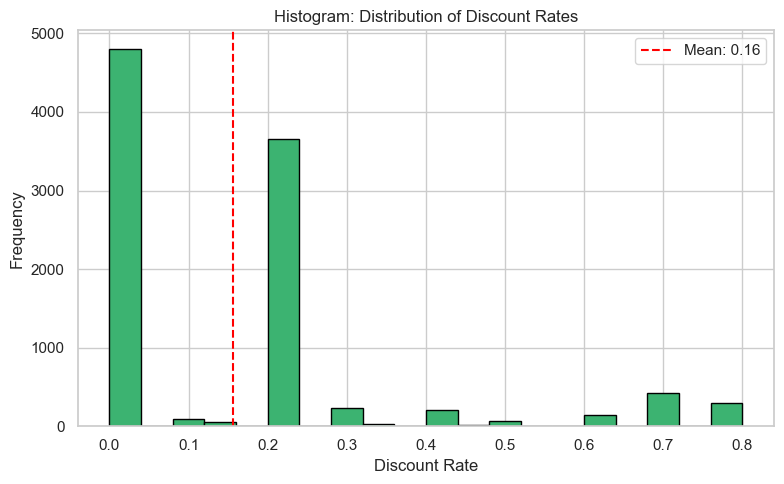

In [16]:
# ---- 2.4  Histogram: Distribution of Discount ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Discount'], bins=20, color='mediumseagreen', edgecolor='black')
ax.axvline(df['Discount'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['Discount'].mean():.2f}")
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Frequency')
ax.set_title('Histogram: Distribution of Discount Rates')
ax.legend()
plt.tight_layout()
plt.savefig('viz_histogram.png', dpi=150)
plt.show()

**Insight – Histogram:** The discount distribution is right-skewed with the majority of transactions receiving 0–20% discount. A notable spike exists at 0% (no discount) and another at 20%. Very high discounts (>50%) are rare but present, and those are the transactions most likely to generate losses as seen in the scatter plot.

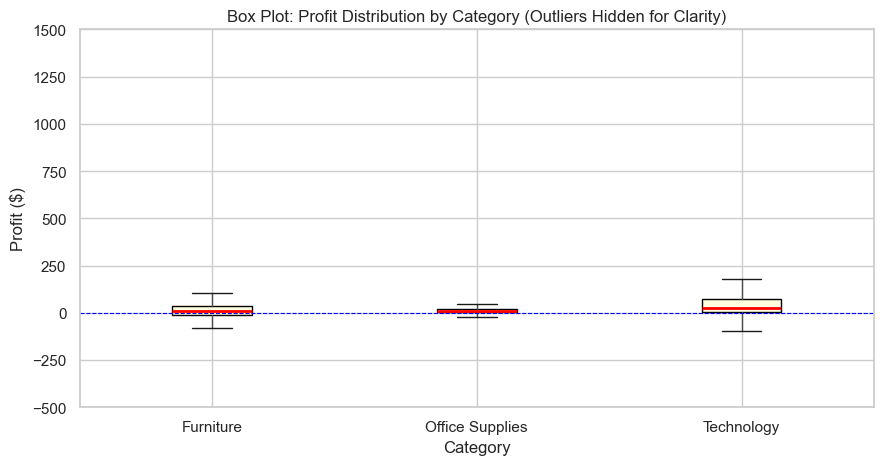

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
df.boxplot(column='Profit', by='Category', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='lightyellow', color='black'),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.4),
           showfliers=False)   # hide extreme outliers so boxes are visible
ax.set_xlabel('Category')
ax.set_ylabel('Profit ($)')
ax.set_title('Box Plot: Profit Distribution by Category (Outliers Hidden for Clarity)')
ax.axhline(0, color='blue', linestyle='--', linewidth=0.8)
ax.set_ylim(-500, 1500)   # zoom into the main data range
plt.suptitle('')
plt.tight_layout()
plt.savefig('viz_boxplot.png', dpi=150)
plt.show()

**Insight – Box Plot:** Technology has the highest median profit and widest spread, indicating both high-reward and high-risk transactions. Furniture has a median profit close to zero with many outliers below the zero line (blue dashes), confirming it is the least profitable category. Office Supplies shows a tight, consistent profit range.

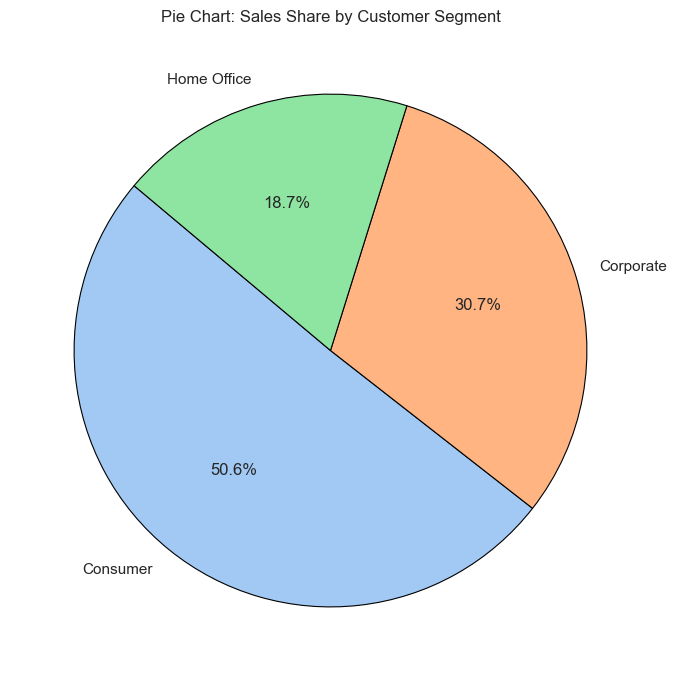

In [20]:
# ---- 2.6  Pie Chart: Sales by Customer Segment ----
segment_sales = df.groupby('Segment')['Sales'].sum()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    segment_sales, labels=segment_sales.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('pastel', len(segment_sales)),
    wedgeprops=dict(edgecolor='black', linewidth=0.8))
ax.set_title('Pie Chart: Sales Share by Customer Segment')
plt.tight_layout()
plt.savefig('viz_pie.png', dpi=150)
plt.show()

**Insight – Pie Chart:** Consumer segment dominates with roughly 50% of total sales, followed by Corporate (~30%) and Home Office (~20%). This indicates the store's primary customer base is individual consumers rather than business buyers, which has implications for marketing strategy and product assortment.

---
### STEP 3: DATA PREPROCESSING

#### 3.1 Handling Missing Values

In [21]:
print('=== Missing Values BEFORE Handling ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')
df.head()

=== Missing Values BEFORE Handling ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing cells: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
df_clean = df.copy()

# Postal Code: fill missing with 00000 (unknown placeholder)
if 'Postal Code' in df_clean.columns:
    df_clean['Postal Code'] = df_clean['Postal Code'].fillna(0).astype(int)

# Drop any rows where key numeric columns are null
df_clean.dropna(subset=['Sales', 'Profit', 'Quantity', 'Discount'], inplace=True)

print('=== Missing Values AFTER Handling ===')
print(df_clean.isnull().sum())
print(f'\nTotal missing cells: {df_clean.isnull().sum().sum()}')
print(f'Rows remaining: {len(df_clean)}')
df_clean.head()

=== Missing Values AFTER Handling ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total missing cells: 0
Rows remaining: 9994


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#### 3.2 Outlier Detection and Removal

In [23]:
# IQR method on Sales column
Q1  = df_clean['Sales'].quantile(0.25)
Q3  = df_clean['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('=== IQR Calculation for Sales ===')
print(f'  Q1 (25th percentile) : ${Q1:.2f}')
print(f'  Q3 (75th percentile) : ${Q3:.2f}')
print(f'  IQR                  : ${IQR:.2f}')
print(f'  Lower Bound          : ${lower_bound:.2f}')
print(f'  Upper Bound          : ${upper_bound:.2f}')

outliers = df_clean[(df_clean['Sales'] < lower_bound) | (df_clean['Sales'] > upper_bound)]
print(f'\nOutliers detected: {len(outliers)} rows ({len(outliers)/len(df_clean)*100:.1f}%)')
outliers[['Order ID', 'Category', 'Sub-Category', 'Sales', 'Profit']].head(10)

=== IQR Calculation for Sales ===
  Q1 (25th percentile) : $17.28
  Q3 (75th percentile) : $209.94
  IQR                  : $192.66
  Lower Bound          : $-271.71
  Upper Bound          : $498.93

Outliers detected: 1167 rows (11.7%)


,Order ID,Category,Sub-Category,Sales,Profit
1,CA-2016-152156,Furniture,Chairs,731.9400,219.5820
3,US-2015-108966,Furniture,Tables,957.5775,-383.0310
7,CA-2014-115812,Technology,Phones,907.1520,90.7152
10,CA-2014-115812,Furniture,Tables,1706.1840,85.3092
11,CA-2014-115812,Technology,Phones,911.4240,68.3568
16,CA-2014-105893,Office Supplies,Storage,665.8800,13.3176
24,CA-2015-106320,Furniture,Tables,1044.6300,240.2649
27,US-2015-150630,Furniture,Bookcases,3083.4300,-1665.0522
35,CA-2016-117590,Technology,Phones,1097.5440,123.4737
38,CA-2015-117415,Furniture,Bookcases,532.3992,-46.9764


In [24]:
df_no_outliers = df_clean[(df_clean['Sales'] >= lower_bound) & (df_clean['Sales'] <= upper_bound)].copy()

print(f'Shape BEFORE outlier removal: {df_clean.shape}')
print(f'Shape AFTER  outlier removal: {df_no_outliers.shape}')
print()
df_no_outliers[['Sales', 'Profit']].describe().round(2)

Shape BEFORE outlier removal: (9994, 21)
Shape AFTER  outlier removal: (8827, 21)



,Sales,Profit
count,8827.00,8827.00
mean,92.86,11.20
std,114.05,49.07
min,0.44,-1181.28
25%,15.01,1.70
50%,40.88,7.44
75%,124.22,21.34
max,498.26,240.86


#### 3.3 Data Reduction

In [25]:
print('=== BEFORE Data Reduction ===')
print(f'Shape   : {df_no_outliers.shape}')
print(f'Columns : {df_no_outliers.columns.tolist()}')

=== BEFORE Data Reduction ===
Shape   : (8827, 21)
Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [26]:
# Dimension elimination: drop columns not needed for analysis
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                'Country', 'City', 'State', 'Postal Code', 'Product ID',
                'Product Name', 'Ship Date', 'Ship Mode']
cols_to_drop = [c for c in cols_to_drop if c in df_no_outliers.columns]
df_reduced = df_no_outliers.drop(columns=cols_to_drop)

# Row sampling: keep 70% of rows
df_reduced = df_reduced.sample(frac=0.70, random_state=42).reset_index(drop=True)

print('=== AFTER Data Reduction ===')
print(f'Shape   : {df_reduced.shape}')
print(f'Columns : {df_reduced.columns.tolist()}')
df_reduced.head()

=== AFTER Data Reduction ===
Shape   : (6179, 9)
Columns : ['Order Date', 'Segment', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


,Order Date,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-12-31,Corporate,West,Office Supplies,Art,3.640,2,0.0,1.6380
1,2016-12-17,Corporate,West,Office Supplies,Binders,11.416,1,0.2,3.8529
2,2017-07-29,Consumer,West,Furniture,Bookcases,115.960,2,0.0,25.5112
3,2017-07-18,Consumer,East,Furniture,Chairs,198.744,4,0.3,-14.1960
4,2017-07-14,Consumer,East,Office Supplies,Storage,239.456,7,0.2,17.9592


#### 3.4 Data Scaling and Discretization

In [27]:
print('=== BEFORE Scaling ===')
df_reduced[['Sales', 'Profit', 'Quantity', 'Discount']].describe().round(2)

=== BEFORE Scaling ===


,Sales,Profit,Quantity,Discount
count,6179.00,6179.00,6179.00,6179.00
mean,92.03,11.07,3.62,0.16
std,113.65,46.52,2.12,0.21
min,0.56,-766.01,1.00,0.00
25%,15.18,1.70,2.00,0.00
50%,40.24,7.48,3.00,0.20
75%,121.57,21.04,5.00,0.20
max,497.94,240.86,14.00,0.80


In [28]:
df_scaled = df_reduced.copy()

# Min-Max Scaling on Sales and Quantity
mm_scaler = MinMaxScaler()
df_scaled[['Sales', 'Quantity']] = mm_scaler.fit_transform(df_scaled[['Sales', 'Quantity']])

# Z-score Standardization on Profit
df_scaled['Profit_zscore'] = stats.zscore(df_scaled['Profit'])

# Discretize Discount into meaningful categories
bins   = [-0.01, 0.0, 0.2, 0.4, 1.01]
labels = ['No Discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (>40%)']
df_scaled['Discount_Category'] = pd.cut(df_scaled['Discount'], bins=bins, labels=labels)

print('=== AFTER Scaling & Discretization ===')
df_scaled[['Sales', 'Quantity', 'Profit_zscore', 'Discount_Category']].describe(include='all').round(3)

=== AFTER Scaling & Discretization ===


,Sales,Quantity,Profit_zscore,Discount_Category
count,6179.000,6179.000,6179.000,6179
unique,NaN,NaN,NaN,4
top,NaN,NaN,NaN,No Discount
freq,NaN,NaN,NaN,3007
mean,0.184,0.201,0.000,NaN
std,0.229,0.163,1.000,NaN
min,0.000,0.000,-16.705,NaN
25%,0.029,0.077,-0.201,NaN
50%,0.080,0.154,-0.077,NaN
75%,0.243,0.308,0.214,NaN


In [29]:
df_scaled[['Sales', 'Quantity', 'Profit', 'Profit_zscore', 'Discount', 'Discount_Category']].head(8)

,Sales,Quantity,Profit,Profit_zscore,Discount,Discount_Category
0,0.006200,0.076923,1.6380,-0.202836,0.0,No Discount
1,0.021834,0.000000,3.8529,-0.155223,0.2,Low (1-20%)
2,0.232022,0.076923,25.5112,0.310358,0.0,No Discount
3,0.398461,0.230769,-14.1960,-0.543214,0.3,Medium (21-40%)
4,0.480313,0.461538,17.9592,0.148015,0.2,Low (1-20%)
5,0.033624,0.384615,5.0112,-0.130323,0.0,No Discount
6,0.024552,0.384615,4.6284,-0.138552,0.2,Low (1-20%)
7,0.001793,0.000000,0.2353,-0.232989,0.2,Low (1-20%)


---
### STEP 4: STATISTICAL ANALYSIS

#### 4.1 General Overview

In [30]:
# Use outlier-removed, unscaled data for interpretable statistics
df_stat = df_no_outliers.copy()
df_stat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8827 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         8827 non-null   int64         
 1   Order ID       8827 non-null   object        
 2   Order Date     8827 non-null   datetime64[ns]
 3   Ship Date      8827 non-null   datetime64[ns]
 4   Ship Mode      8827 non-null   object        
 5   Customer ID    8827 non-null   object        
 6   Customer Name  8827 non-null   object        
 7   Segment        8827 non-null   object        
 8   Country        8827 non-null   object        
 9   City           8827 non-null   object        
 10  State          8827 non-null   object        
 11  Postal Code    8827 non-null   int64         
 12  Region         8827 non-null   object        
 13  Product ID     8827 non-null   object        
 14  Category       8827 non-null   object        
 15  Sub-Category   8827 non-nu

In [31]:
df_stat.describe().round(2)

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,8827.00,8827,8827,8827.00,8827.00,8827.00,8827.00,8827.00
mean,5016.38,2016-05-02 15:45:12.541067264,2016-05-06 14:57:05.036818688,55373.64,92.86,3.61,0.16,11.20
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.00,0.44,1.00,0.00,-1181.28
25%,2508.50,2015-05-28 00:00:00,2015-05-31 00:00:00,23320.00,15.01,2.00,0.00,1.70
50%,5028.00,2016-07-01 00:00:00,2016-07-03 00:00:00,59801.00,40.88,3.00,0.20,7.44
75%,7517.50,2017-05-15 00:00:00,2017-05-19 00:00:00,90008.00,124.22,5.00,0.20,21.34
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,498.26,14.00,0.80,240.86
std,2888.41,NaN,NaN,31974.54,114.05,2.13,0.21,49.07


#### 4.2 Central Tendency Measures

In [32]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

central = pd.DataFrame({
    'Min':    df_stat[num_cols].min(),
    'Max':    df_stat[num_cols].max(),
    'Mean':   df_stat[num_cols].mean().round(3),
    'Median': df_stat[num_cols].median(),
    'Mode':   df_stat[num_cols].mode().iloc[0]
})

print('=== Central Tendency Measures ===')
central

=== Central Tendency Measures ===


,Min,Max,Mean,Median,Mode
Sales,0.4440,498.2600,92.865,40.8800,12.96
Quantity,1.0000,14.0000,3.609,3.0000,2.00
Discount,0.0000,0.8000,0.158,0.2000,0.00
Profit,-1181.2824,240.8595,11.199,7.4376,0.00


#### 4.3 Dispersion Measures

In [33]:
q1_vals = df_stat[num_cols].quantile(0.25)
q3_vals = df_stat[num_cols].quantile(0.75)

dispersion = pd.DataFrame({
    'Range':    df_stat[num_cols].max() - df_stat[num_cols].min(),
    'Q1':       q1_vals.round(3),
    'Q3':       q3_vals.round(3),
    'IQR':      (q3_vals - q1_vals).round(3),
    'Variance': df_stat[num_cols].var().round(3),
    'Std Dev':  df_stat[num_cols].std().round(3)
})

print('=== Dispersion Measures ===')
dispersion

=== Dispersion Measures ===


,Range,Q1,Q3,IQR,Variance,Std Dev
Sales,497.8160,15.008,124.225,109.217,13006.280,114.045
Quantity,13.0000,2.000,5.000,3.000,4.534,2.129
Discount,0.8000,0.000,0.200,0.200,0.045,0.212
Profit,1422.1419,1.702,21.335,19.633,2407.482,49.066


#### 4.4 Correlation Analysis

=== Correlation Matrix ===
          Sales  Quantity  Discount  Profit
Sales     1.000     0.162    -0.075   0.196
Quantity  0.162     1.000     0.017   0.094
Discount -0.075     0.017     1.000  -0.458
Profit    0.196     0.094    -0.458   1.000


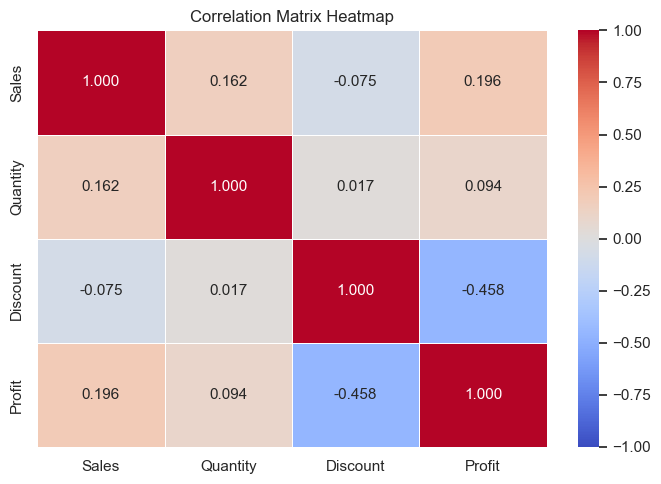

In [35]:
corr_matrix = df_stat[num_cols].corr().round(3)

print('=== Correlation Matrix ===')
print(corr_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('viz_correlation.png', dpi=150)
plt.show()

**Insight – Correlation Matrix:** Discount and Profit show a notable **negative correlation**, confirming that higher discounts directly erode profitability — this is the most actionable finding for business decisions. Sales and Profit have a moderate positive correlation. Quantity has very little correlation with Profit or Sales, suggesting the store's pricing is consistent regardless of order size.